## Курсов проект: Random Forest за предсказване на игрова позиция в NBA

**Метод:** Random Forest (случайна гора)
**Данни:** NBA Players Data — Kaggle (`justinas/nba-players-data`), допълнени с колона `Pos` от историческия датасет *Seasons_Stats* (1950–2017).

**Задача:** многокласова класификация — на база физически данни и сезонна статистика на играч да предскажем неговата **игрова позиция** (PG, SG, SF, PF, C).

**Стъпки:**
1. Обединяване и подготовка на данните
2. Разведочен анализ (EDA)
3. Обучение на модел с Random Forest
4. K-Fold кръстосана валидация
5. Оптимизация на хиперпараметри + визуализация
6. Визуализация на резултатите
7. Сравнение с Decision Tree и XGBoost
8. Допълнителен експеримент: 3 класа (Guard / Forward / Center)
9. Сравнение с други анализи в Kaggle

### Източник на данните и възпроизводимост

Проектът използва два публични датасета от Kaggle. За изпълнение поставете файловете в папка `data/`:

| Файл | Kaggle датасет |
|---|---|
| `all_seasons.csv` | [justinas/nba-players-data](https://www.kaggle.com/datasets/justinas/nba-players-data) |
| `Seasons_Stats.csv` | [drgilermo/nba-players-stats](https://www.kaggle.com/datasets/drgilermo/nba-players-stats) |

**Автоматично сваляне (по избор)** — изисква `kagglehub` и Kaggle акаунт:

```python
# pip install kagglehub
import kagglehub, shutil, os
os.makedirs('data', exist_ok=True)
p1 = kagglehub.dataset_download('justinas/nba-players-data')
p2 = kagglehub.dataset_download('drgilermo/nba-players-stats')
shutil.copy(os.path.join(p1, 'all_seasons.csv'),   'data/all_seasons.csv')
shutil.copy(os.path.join(p2, 'Seasons_Stats.csv'), 'data/Seasons_Stats.csv')
```

*Забележка:* всички резултати и графики по-долу вече са изчислени и запазени в notebook-а.

## 1. Теоретична част — Random Forest

### 1.1. Дърво на решенията
**Decision Tree** рекурсивно разделя пространството на признаците на правоъгълни области.
При всяко разделяне се избира признакът и прагът, които най-добре намаляват *примесите* на възлите —
обикновено чрез **Gini индекс** или **ентропия**. Едно дърво е лесно за интерпретация, но е
*нестабилно* и силно склонно към **преобучение** (overfitting) — малка промяна в данните води до съвсем
друго дърво.

### 1.2. Ансамблов подход — Bagging
**Bagging** намалява дисперсията: създават се множество bootstrap извадки от обучаващото множество, върху всяка се обучава по едно дърво, а
прогнозите се усредняват. Тъй като дърветата са обучени върху различни извадки, техните грешки частично се компенсират.

### 1.3. Random Forest
Random Forest надгражда bagging с още един източник на случайност: **при всяко разделяне** дървото
разглежда само случайно подмножество от признаците (`max_features`). Това **декорелира** дърветата —
ако един признак е много силен, той вече не доминира всяко дърво — и прави ансамбъла по-устойчив.

Ключови свойства:
- Прогноза = мнозинство от гласовете на всички дървета.
- **OOB (out-of-bag) оценка** — всяко дърво може да се валидира върху извадката, която не е попаднала в неговия bootstrap.
- **Feature importance** — измерва средното намаление на примесите, дължащо се на всеки признак.

### 1.4. Основни хиперпараметри
| Параметър | Роля |
|---|---|
| `n_estimators` | брой дървета — повече дървета = по-стабилно, но по-бавно |
| `max_depth` | максимална дълбочина — ограничава преобучението |
| `min_samples_split` / `min_samples_leaf` | минимален брой примери за разделяне / в лист |
| `max_features` | брой признаци, разглеждани при разделяне |

### 1.5. Предимства и недостатъци
**Предимства:** висока точност; устойчивост на преобучение; работи с нелинейни зависимости без скалиране на признаците; дава важност на признаците; устойчив на шум и отскоци; лесно паралелизуем.

**Недостатъци:** по-бавен и по-обемен от едно дърво; по-слабо интерпретируем; при силно припокриващи се класове може да греши между съседни класове; слаб при екстраполация.

### 1.6. Сравнение с другите използвани методи
- **спрямо Decision Tree** — Random Forest жертва интерпретируемостта на единичното дърво в замяна на чувствително по-висока точност и стабилност.
- **спрямо XGBoost** — boosting изгражда дърветата *последователно*, като всяко следващо коригира грешките на предходните. XGBoost често постига малко по-висока точност, но е по-чувствителен към хиперпараметрите и към преобучение. Random Forest се настройва по-лесно и е напълно паралелизуем.

## 2. Практическа част

### 2.1. Импортиране на библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, GroupShuffleSplit,
                                     KFold, GroupKFold, cross_val_score,
                                     GridSearchCV, validation_curve)
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import shap

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42

### 2.2. Зареждане на данните

Използваме два датасета:
- **`all_seasons.csv`** — основният датасет (Kaggle, *justinas/nba-players-data*); един ред = играч × сезон, 1996–2023. Съдържа признаците, но **няма позиция**.
- **`Seasons_Stats.csv`** — историческа NBA статистика 1950–2017; съдържа колоната `Pos`, от която ще извлечем позицията.

In [2]:
all_seasons = pd.read_csv('data/all_seasons.csv', index_col=0)
seasons_stats = pd.read_csv('data/Seasons_Stats.csv', index_col=0)

print('all_seasons :', all_seasons.shape)
print('seasons_stats:', seasons_stats.shape)
all_seasons.head()

all_seasons : (12844, 21)
seasons_stats: (24691, 52)


,player_name,team_abbreviation,age,player_height,player_weight,college,country,draft_year,draft_round,draft_number,...,pts,reb,ast,net_rating,oreb_pct,dreb_pct,usg_pct,ts_pct,ast_pct,season
0,Randy Livingston,HOU,22.0,193.04,94.800728,Louisiana State,USA,1996,2,42,...,3.9,1.5,2.4,0.3,0.042,0.071,0.169,0.487,0.248,1996-97
1,Gaylon Nickerson,WAS,28.0,190.50,86.182480,Northwestern Oklahoma,USA,1994,2,34,...,3.8,1.3,0.3,8.9,0.030,0.111,0.174,0.497,0.043,1996-97
2,George Lynch,VAN,26.0,203.20,103.418976,North Carolina,USA,1993,1,12,...,8.3,6.4,1.9,-8.2,0.106,0.185,0.175,0.512,0.125,1996-97
3,George McCloud,LAL,30.0,203.20,102.058200,Florida State,USA,1989,1,7,...,10.2,2.8,1.7,-2.7,0.027,0.111,0.206,0.527,0.125,1996-97
4,George Zidek,DEN,23.0,213.36,119.748288,UCLA,USA,1995,1,22,...,2.8,1.7,0.3,-14.1,0.102,0.169,0.195,0.500,0.064,1996-97


### 2.3. Обединяване — добавяне на целевата променлива `Pos`

Основният датасет няма позиция, затова я взимаме от `Seasons_Stats`. Стъпки:
1. Запазваме само **чистите 5 позиции** (PG, SG, SF, PF, C); отпадат хибридните означения (`PG-SG`, `F-C` и т.н.) и архаичните (`G`, `F`).
2. За всеки играч определяме **основната му позиция** — тази, на която е изиграл **най-много мачове** през кариерата си (претегляне по брой мачове `G`, а не просто по брой сезони). Позицията е сравнително стабилна, така че едно етикетиране на играч е разумно и ни позволява да запазим максимум редове.
3. Свързваме по име на играч и присвояваме `Pos` на всеки негов сезон в основния датасет.

In [3]:
PURE_POS = ['PG', 'SG', 'SF', 'PF', 'C']

ss = seasons_stats[seasons_stats['Pos'].isin(PURE_POS)].dropna(subset=['Player'])

# Основната позиция на всеки играч = позицията, на която е изиграл НАЙ-МНОГО мачове (G)
# през кариерата си. Това е по-точно от просто броене на сезони: играч с 70 мача като PG
# и 20 като SG трябва да е PG, дори ако сезоните на SG са повече.
pos_games = ss.groupby(['Player', 'Pos'])['G'].sum()
modal_pos = pos_games.groupby('Player').idxmax().apply(lambda t: t[1])
print(f'Играчи с позиция: {len(modal_pos)}')

df = all_seasons.copy()
df['Pos'] = df['player_name'].map(modal_pos)

print(f'Редове общо           : {len(all_seasons)}')
print(f'Редове с намерена Pos  : {df["Pos"].notna().sum()}')
print(f'Несъвпаднали (отпадат) : {df["Pos"].isna().sum()}')

Играчи с позиция: 3679
Редове общо           : 12844
Редове с намерена Pos  : 10693
Несъвпаднали (отпадат) : 2151


### 2.4. Избор на признаци и почистване

Признаци за обучение (13 на брой) — физически данни и сезонна статистика:
- **физически:** ръст, тегло, възраст
- **продуктивност:** изиграни мачове, точки, борби, асистенции
- **разширени метрики:** net rating, % офанзивни/дефанзивни борби, usage rate, true shooting %, assist %

In [4]:
FEATURES = ['player_height', 'player_weight', 'age', 'gp',
            'pts', 'reb', 'ast', 'net_rating',
            'oreb_pct', 'dreb_pct', 'usg_pct', 'ts_pct', 'ast_pct']

data = df.dropna(subset=FEATURES + ['Pos']).reset_index(drop=True)
print(f'Краен набор: {data.shape[0]} реда, {data["player_name"].nunique()} уникални играчи')

X = data[FEATURES]
le = LabelEncoder()
y = le.fit_transform(data['Pos'])
groups = data['player_name']          # за груповата кръстосана валидация
CLASS_NAMES = list(le.classes_)
print('Класове:', CLASS_NAMES)

Краен набор: 10693 реда, 1806 уникални играчи
Класове: ['C', 'PF', 'PG', 'SF', 'SG']


### 2.5. Разведочен анализ (EDA)

Проверяваме баланса на класовете и как ключови признаци разделят позициите.

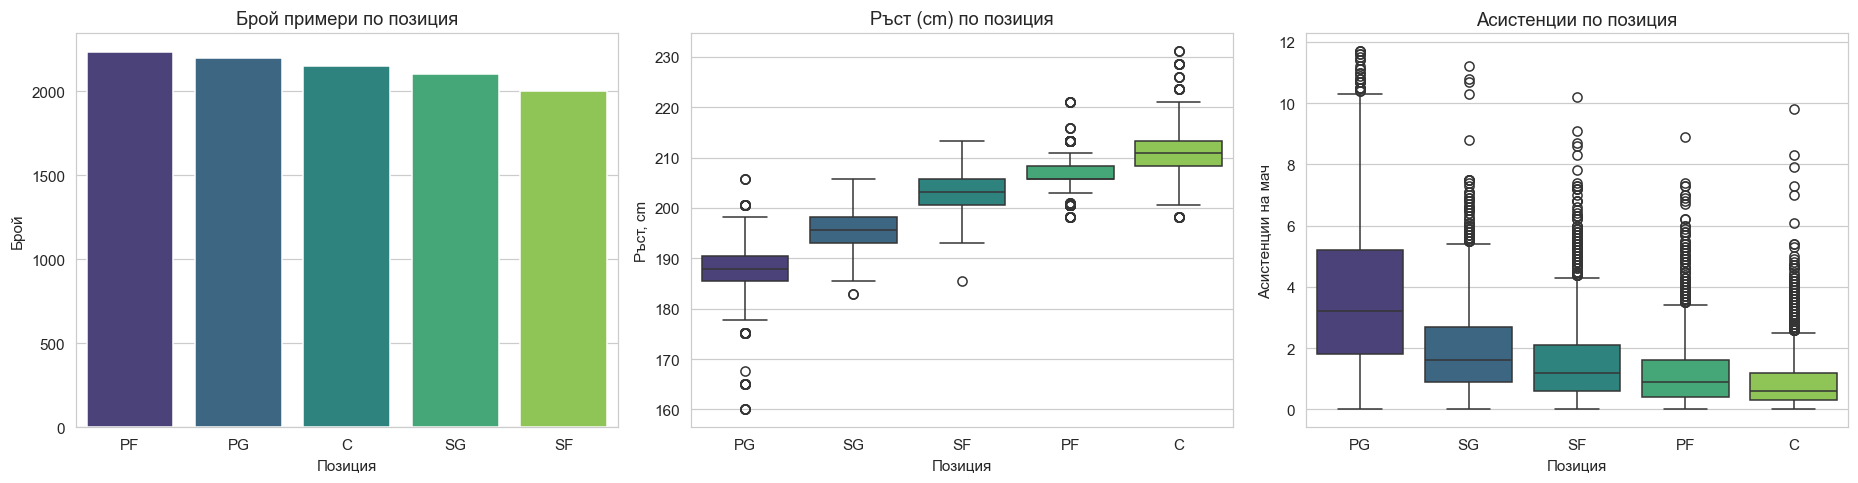

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

# баланс на класовете
order = data['Pos'].value_counts().index
sns.countplot(data=data, x='Pos', order=order, ax=axes[0], palette='viridis')
axes[0].set_title('Брой примери по позиция')
axes[0].set_xlabel('Позиция'); axes[0].set_ylabel('Брой')

# ръст по позиция
sns.boxplot(data=data, x='Pos', y='player_height', order=PURE_POS,
            ax=axes[1], palette='viridis')
axes[1].set_title('Ръст (cm) по позиция')
axes[1].set_xlabel('Позиция'); axes[1].set_ylabel('Ръст, cm')

# асистенции по позиция
sns.boxplot(data=data, x='Pos', y='ast', order=PURE_POS,
            ax=axes[2], palette='viridis')
axes[2].set_title('Асистенции по позиция')
axes[2].set_xlabel('Позиция'); axes[2].set_ylabel('Асистенции на мач')

plt.tight_layout(); plt.show()

Класовете са **добре балансирани** (~2000–2300 примера на позиция), затова няма да се налага
претегляне. Виждат се ясни закономерности: ръстът расте монотонно от PG към C, а асистенциите са
огледалната тенденция — разпределителите (PG) асистират най-много. Това са силни сигнали за модела.

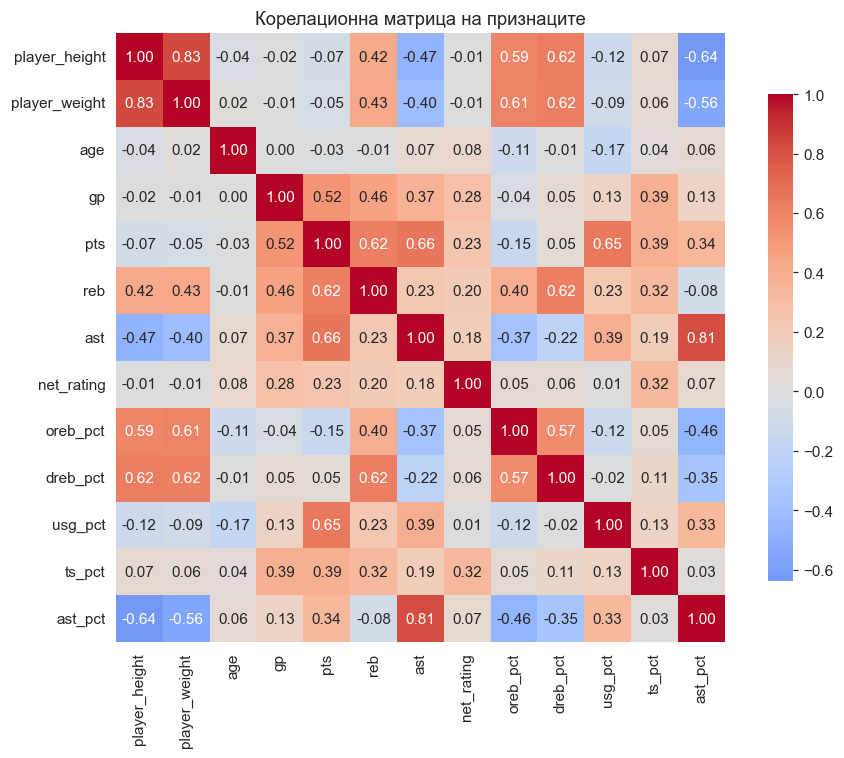

In [6]:
# корелация между признаците
plt.figure(figsize=(9, 7))
sns.heatmap(X.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, cbar_kws={'shrink': 0.8})
plt.title('Корелационна матрица на признаците')
plt.tight_layout(); plt.show()

### 2.6. Разделяне на обучаващо и тестово множество

**Важно методологично уточнение.** Един играч присъства с няколко сезона (реда). Ако разделим
редовете напълно случайно, сезони на един и същ играч ще попаднат едновременно в обучаващото и
тестовото множество — а играчите запазват позицията си. Това е **изтичане на данни (data leakage)**
и завишава изкуствено точността.

Затова разделяме **по играч** (`GroupShuffleSplit`) — всички сезони на даден играч са изцяло или в
обучаващото, или в тестовото множество. По-долу ще покажем количествено колко важна е тази разлика.

In [7]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train = groups.iloc[train_idx]

print(f'Обучаващо: {X_train.shape[0]} реда')
print(f'Тестово  : {X_test.shape[0]} реда')
assert set(groups.iloc[train_idx]) & set(groups.iloc[test_idx]) == set(), 'има застъпване!'
print('Няма застъпване на играчи между двете множества.')

Обучаващо: 8566 реда
Тестово  : 2127 реда
Няма застъпване на играчи между двете множества.


### 2.7. Обучение на модел с Random Forest

In [8]:
rf = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE,
                            n_jobs=-1, oob_score=True)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

print(f'OOB точност          : {rf.oob_score_:.4f}')
print(f'Точност върху тест    : {acc_rf:.4f}')
print()
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES))

OOB точност          : 0.8465
Точност върху тест    : 0.7612

              precision    recall  f1-score   support

           C       0.86      0.86      0.86       472
          PF       0.67      0.73      0.70       408
          PG       0.86      0.91      0.88       408
          SF       0.66      0.59      0.62       412
          SG       0.74      0.70      0.72       427

    accuracy                           0.76      2127
   macro avg       0.76      0.76      0.76      2127
weighted avg       0.76      0.76      0.76      2127



**Внимание — двете показани числа са от различни оценки и не са пряко сравними:**
- **Точност върху тест ≈ 0.76** е резултат от **един-единствен** случаен split по играчи. Това е само **една реализация** с разброс от порядъка на ±2–3 пр.п. — от нея сама по себе си не бива да се правят твърди изводи.
- **OOB оценка ≈ 0.85** изглежда по-висока, но е **подвеждаща** за нашата задача: OOB примерите идват от *същите играчи*, които участват и в обучението (просто не са попаднали в bootstrap-а на конкретното дърво). Тоест OOB страда от същото **изтичане на данни по играч**, което ще демонстрираме в т. 2.8.

Затова **надеждната** оценка ще получим чак в следващата точка чрез 10-кратна групова кръстосана валидация (`GroupKFold`).

От подробния отчет се вижда, че моделът е най-уверен за крайните позиции (**C** и **PG**), а най-често бърка между **съседните** позиции (SG↔SF, SF↔PF) — което е очаквано, защото те се припокриват и в реалната игра.

### 2.8. K-Fold кръстосана валидация и проблемът с изтичането на данни

Изискването на проекта е да се приложи кръстосана валидация. Тук правим **директно сравнение**
между два варианта на 10-кратна кръстосана валидация:
- **обикновен `KFold`** — редовете се разделят случайно (сезони на един играч попадат и в двете части);
- **`GroupKFold`** — разделяне по играч, без изтичане на данни.

In [9]:
kf = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
cv_kfold = cross_val_score(rf, X, y, cv=kf, scoring='accuracy', n_jobs=-1)

gkf = GroupKFold(n_splits=10)
cv_group = cross_val_score(rf, X, y, cv=gkf, groups=groups,
                           scoring='accuracy', n_jobs=-1)

print(f'KFold (случаен)    : {cv_kfold.mean():.4f}  +/- {cv_kfold.std()*2:.4f}')
print(f'GroupKFold (играч) : {cv_group.mean():.4f}  +/- {cv_group.std()*2:.4f}')
print(f'Завишение от изтичане на данни: {(cv_kfold.mean()-cv_group.mean())*100:.1f} проц. пункта')

KFold (случаен)    : 0.8368  +/- 0.0294
GroupKFold (играч) : 0.7742  +/- 0.0625
Завишение от изтичане на данни: 6.3 проц. пункта


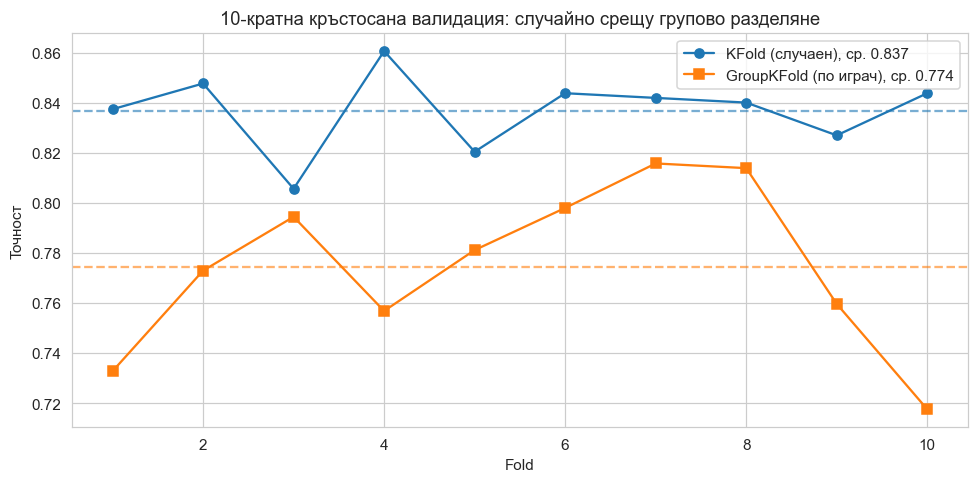

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
folds = range(1, 11)
ax.plot(folds, cv_kfold, 'o-', label=f'KFold (случаен), ср. {cv_kfold.mean():.3f}')
ax.plot(folds, cv_group, 's-', label=f'GroupKFold (по играч), ср. {cv_group.mean():.3f}')
ax.axhline(cv_kfold.mean(), ls='--', color='C0', alpha=.6)
ax.axhline(cv_group.mean(), ls='--', color='C1', alpha=.6)
ax.set_xlabel('Fold'); ax.set_ylabel('Точност')
ax.set_title('10-кратна кръстосана валидация: случайно срещу групово разделяне')
ax.legend(); plt.tight_layout(); plt.show()

In [11]:
# Обобщение на четирите оценки на точността — за да е ясно кое какво измерва
metrics_summary = pd.DataFrame([
    {'Оценка': 'OOB',            'Точност': rf.oob_score_,  'Честна?': 'НЕ — изтичане по играч'},
    {'Оценка': 'KFold-10',       'Точност': cv_kfold.mean(),'Честна?': 'НЕ — изтичане по играч'},
    {'Оценка': 'Holdout (1 split)','Точност': acc_rf,       'Честна?': 'частично — само 1 реализация (шум)'},
    {'Оценка': 'GroupKFold-10',  'Точност': cv_group.mean(),'Честна?': 'ДА — реална обобщаваща способност'},
])
metrics_summary

,Оценка,Точност,Честна?
0,OOB,0.846486,НЕ — изтичане по играч
1,KFold-10,0.836811,НЕ — изтичане по играч
2,Holdout (1 split),0.761166,частично — само 1 реализация (шум)
3,GroupKFold-10,0.774247,ДА — реална обобщаваща способност


**Извод.** Случайният `KFold` дава ~**0.84**, а коректният `GroupKFold` — ~**0.78**. Разликата от
около 6 процентни пункта е чисто **изтичане на данни**: моделът „разпознава" играча, а не научава
самата позиция. Това е важен методологичен момент за датасет от тип *играч × сезон* — реалната
обобщаваща способност на модела е тази при `GroupKFold`. Нататък използваме групова валидация.

### 2.9. Оптимизация на хиперпараметри

Първо разглеждаме **поотделно** влиянието на два ключови хиперпараметъра чрез валидационни криви,
след което правим пълно решетъчно търсене (`GridSearchCV`) с групова кръстосана валидация.

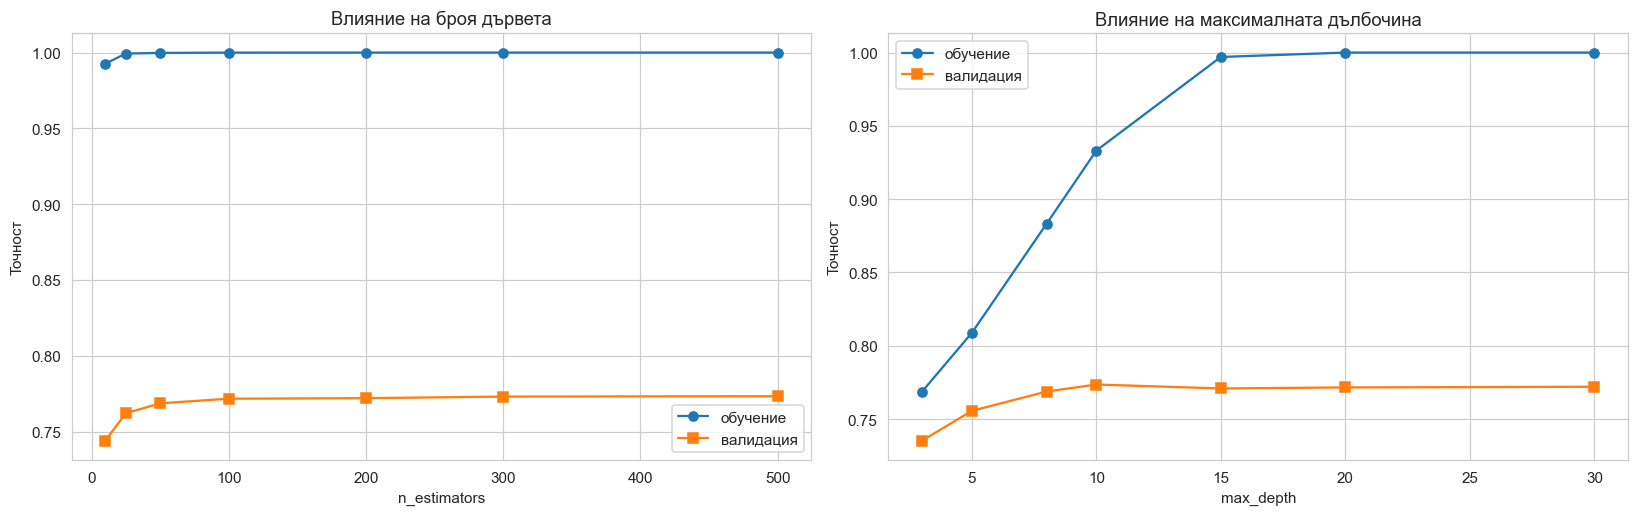

In [12]:
# --- валидационни криви ---
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

# n_estimators
n_range = [10, 25, 50, 100, 200, 300, 500]
tr, va = validation_curve(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    X_train, y_train, param_name='n_estimators', param_range=n_range,
    cv=GroupKFold(5), groups=groups_train, scoring='accuracy', n_jobs=-1)
axes[0].plot(n_range, tr.mean(1), 'o-', label='обучение')
axes[0].plot(n_range, va.mean(1), 's-', label='валидация')
axes[0].set_xlabel('n_estimators'); axes[0].set_ylabel('Точност')
axes[0].set_title('Влияние на броя дървета'); axes[0].legend()

# max_depth
d_range = [3, 5, 8, 10, 15, 20, 30]
tr, va = validation_curve(
    RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    X_train, y_train, param_name='max_depth', param_range=d_range,
    cv=GroupKFold(5), groups=groups_train, scoring='accuracy', n_jobs=-1)
axes[1].plot(d_range, tr.mean(1), 'o-', label='обучение')
axes[1].plot(d_range, va.mean(1), 's-', label='валидация')
axes[1].set_xlabel('max_depth'); axes[1].set_ylabel('Точност')
axes[1].set_title('Влияние на максималната дълбочина'); axes[1].legend()

plt.tight_layout(); plt.show()

Кривите показват типично поведение: точността при **обучение** расте с дълбочината, докато
точността при **валидация** излиза на плато — голямата разлика между двете при висок `max_depth` е
**преобучение**. Броят дървета над ~200 почти не подобрява резултата.

*Забележка:* всяка крива изменя **само един** хиперпараметър, а останалите са фиксирани на разумни стойности (за `max_depth` кривата — `n_estimators=200`; за `n_estimators` кривата — `max_depth=None`). Затова кривите показват тенденцията на всеки параметър поотделно, а съвместният оптимум търсим със `GridSearchCV` по-долу.

In [13]:
param_grid = {
    'n_estimators':      [200, 300],
    'max_depth':         [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1),
    param_grid, cv=GroupKFold(5), scoring='accuracy', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train, groups=groups_train)

print('Най-добри параметри:', grid.best_params_)
print(f'Най-добра CV точност: {grid.best_score_:.4f}')

best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)
print(f'Точност на тест (оптимизиран): {acc_best:.4f}  (базов: {acc_rf:.4f})')

Fitting 5 folds for each of 144 candidates, totalling 720 fits


Най-добри параметри: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 10, 'n_estimators': 200}
Най-добра CV точност: 0.7778
Точност на тест (оптимизиран): 0.7663  (базов: 0.7612)


Оптимизацията дава **много малък прираст** спрямо базовия модел (от порядъка на десети от процента). Това **не е разочароващ резултат, а потвърждение** на едно от ключовите предимства на Random Forest: моделът работи близо до оптимума при широк диапазон от хиперпараметри и **не изисква фино настройване**, за да даде добри резултати. Именно тази устойчивост (за разлика напр. от boosting методите, които са по-чувствителни) го прави толкова популярен на практика.

### 2.10. Визуализация на резултатите

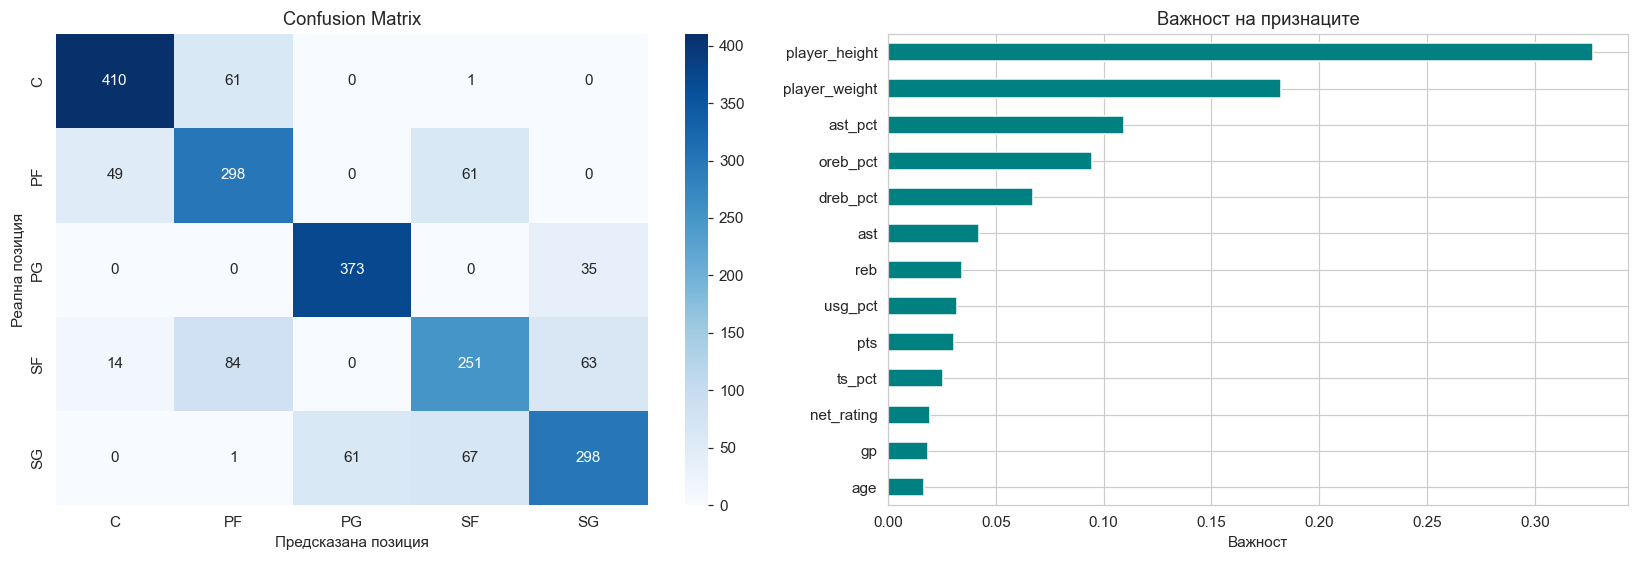

Топ 5 признака:
  player_height      0.327
  player_weight      0.182
  ast_pct            0.109
  oreb_pct           0.094
  dreb_pct           0.067


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=axes[0])
axes[0].set_xlabel('Предсказана позиция'); axes[0].set_ylabel('Реална позиция')
axes[0].set_title('Confusion Matrix')

# feature importance
imp = pd.Series(best_rf.feature_importances_, index=FEATURES).sort_values()
imp.plot.barh(ax=axes[1], color='teal')
axes[1].set_xlabel('Важност'); axes[1].set_title('Важност на признаците')

plt.tight_layout(); plt.show()

print('Топ 5 признака:')
for name, val in imp.sort_values(ascending=False).head().items():
    print(f'  {name:18s} {val:.3f}')

Матрицата на грешките потвърждава: грешките се струпват по **диагоналните съседи** — моделът
почти никога не бърка C с PG, но често бърка SG↔SF. Важността на признаците показва, че **ръстът,
теглото** и съотношението **борби/асистенции** носят почти цялата разделяща информация — точно
интуицията за баскетболните позиции.

### 2.11. Обяснителен ИИ с SHAP

Докато Feature Importance ни показва общото влияние на признаците, използването на библиотека като **SHAP** ни позволява да разберем *точните причини* за предсказанието на всеки индивидуален играч (напр. "този играч е класифициран като център, защото ръстът му добавя огромна вероятност за това").

SHAP Summary Plot за клас 'C' (Глобална важност):

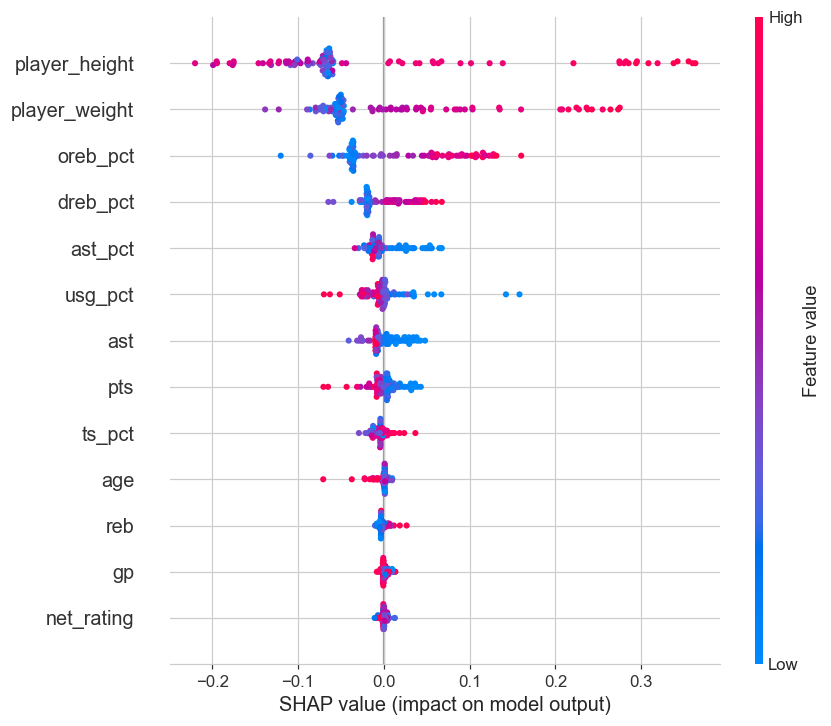

Waterfall Plot: Локално обяснение защо конкретен играч е класифициран като 'C':


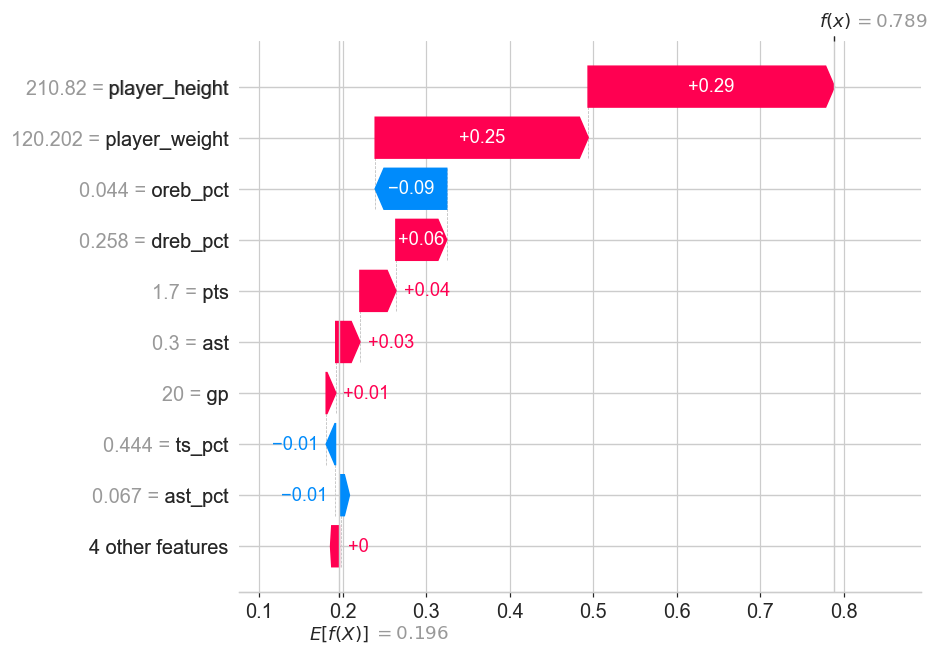

In [15]:
import shap
shap.initjs()
# Инициализация на TreeExplainer за Random Forest
explainer = shap.TreeExplainer(best_rf)

# Изчисляваме SHAP стойностите за малка извадка (100 примера), за да не бавим notebook-a
X_sample = X_test.head(100)
shap_obj = explainer(X_sample)

# Намираме индекса на класа Center ('C')
c_idx = CLASS_NAMES.index('C')

print("SHAP Summary Plot за клас 'C' (Глобална важност):")
shap.summary_plot(shap_obj[:, :, c_idx], X_sample)

print("Waterfall Plot: Локално обяснение защо конкретен играч е класифициран като 'C':")
preds = best_rf.predict(X_sample)
center_indices = np.where(preds == c_idx)[0]
if len(center_indices) > 0:
    idx = center_indices[0]
    shap.plots.waterfall(shap_obj[idx, :, c_idx])
else:
    print("Няма играчи класифицирани като 'C' в тази извадка.")


### 2.12. Сравнение с Decision Tree и XGBoost

Сравняваме оптимизирания Random Forest с:
- **Decision Tree** — едно дърво (базова линия, за да се види ефектът на ансамбъла);
- **XGBoost** — gradient boosting, използван тук **като допълнителен метод**.

Всички модели се оценяват с една и съща групова кръстосана валидация и върху едно и също тестово множество.

In [16]:
dt = DecisionTreeClassifier(random_state=RANDOM_STATE)
xgb = XGBClassifier(random_state=RANDOM_STATE, n_jobs=-1,
                    eval_metric='mlogloss', verbosity=0)

models = {
    'Decision Tree': dt,
    'Random Forest (базов)': rf,
    'Random Forest (оптим.)': best_rf,
    'XGBoost': xgb,
}

rows = []
for name, model in models.items():
    cv = cross_val_score(model, X, y, cv=GroupKFold(10), groups=groups,
                         scoring='accuracy', n_jobs=-1)
    model.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, model.predict(X_test))
    rows.append({'Модел': name, 'CV точност (GroupKFold)': cv.mean(),
                 'CV ст. откл.': cv.std(), 'Точност на тест': test_acc})

results = pd.DataFrame(rows)
results

,Модел,CV точност (GroupKFold),CV ст. откл.,Точност на тест
0,Decision Tree,0.691296,0.027748,0.686883
1,Random Forest (базов),0.774247,0.031257,0.761166
2,Random Forest (оптим.),0.775834,0.031331,0.766338
3,XGBoost,0.760875,0.025410,0.746591


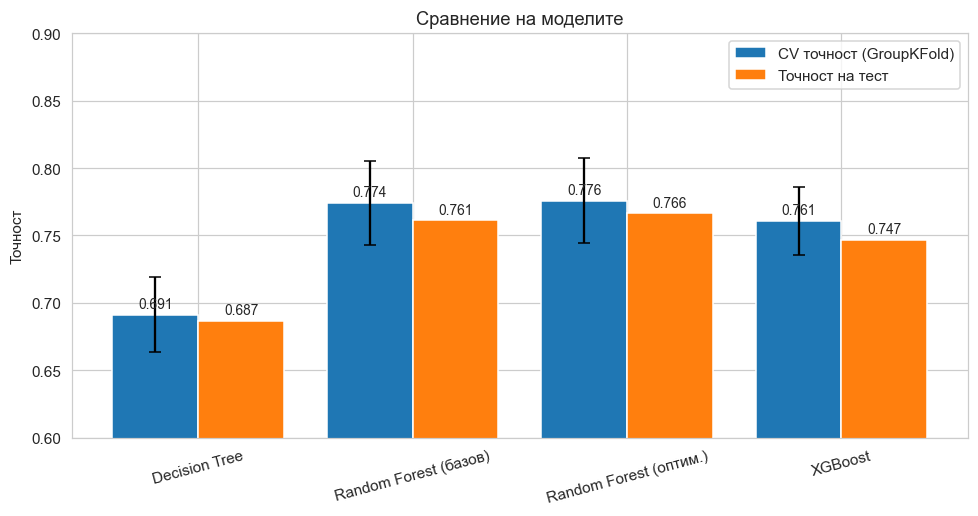

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.8))
xpos = np.arange(len(results))
ax.bar(xpos - 0.2, results['CV точност (GroupKFold)'], 0.4,
       yerr=results['CV ст. откл.'], capsize=4, label='CV точност (GroupKFold)')
ax.bar(xpos + 0.2, results['Точност на тест'], 0.4, label='Точност на тест')
ax.set_xticks(xpos); ax.set_xticklabels(results['Модел'], rotation=15)
ax.set_ylabel('Точност'); ax.set_ylim(0.6, 0.9)
ax.set_title('Сравнение на моделите')
ax.legend()
for i, (cv, te) in enumerate(zip(results['CV точност (GroupKFold)'],
                                 results['Точност на тест'])):
    ax.text(i-0.2, cv+0.005, f'{cv:.3f}', ha='center', fontsize=9)
    ax.text(i+0.2, te+0.005, f'{te:.3f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

**Изводи от сравнението:**
- **Decision Tree** изостава осезаемо — единичното дърво преобучава и е нестабилно.
- **Random Forest** дава значителен скок спрямо едно дърво — точно ефектът на ансамбъла (намаляване на дисперсията). В таблицата фигурират и *базовият*, и *оптимизираният* RF: базовият е само отправна точка, а основният резултат е оптимизираният модел — двата са почти еднакви, което още веднъж потвърждава устойчивостта на метода.
- **XGBoost** е на практика наравно с Random Forest. На този датасет с ясни, почти линейно разделими сигнали (ръст/тегло) boosting не носи предимство; Random Forest при това се настройва по-лесно.
- Разликите между моделите трябва да се четат **на фона на стандартното отклонение** (колоната `CV ст. откл.` ≈ 0.03): RF и XGBoost се припокриват в рамките на този разброс, докато Decision Tree е извън него — т.е. изоставането му е статистически значимо, а разликата RF↔XGBoost — не.

### 2.13. Допълнителен експеримент: 3 класа (Guard / Forward / Center)

Голяма част от грешките са между **съседни** позиции. Затова обединяваме петте позиции в три
по-едри групи и проверяваме хипотезата, че така точността нараства:
- **Guard** = PG + SG
- **Forward** = SF + PF
- **Center** = C

5 класа (PG/SG/SF/PF/C)   : 0.7758
3 класа (Guard/Fwd/Center): 0.8689


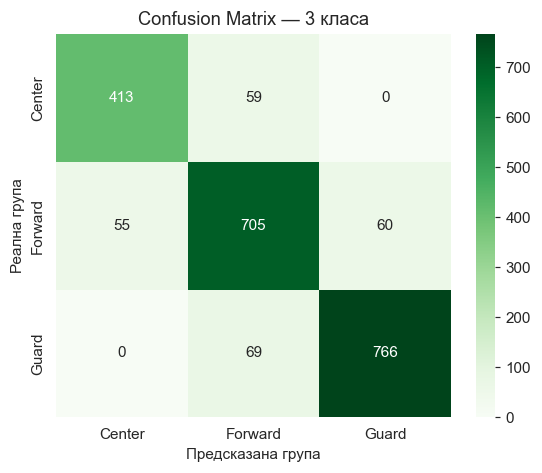

In [18]:
from sklearn.base import clone

GROUP_MAP = {'PG': 'Guard', 'SG': 'Guard',
             'SF': 'Forward', 'PF': 'Forward', 'C': 'Center'}
le3 = LabelEncoder()
y3 = le3.fit_transform(data['Pos'].map(GROUP_MAP))
CLASS3 = list(le3.classes_)

cv5 = cross_val_score(best_rf, X, y,  cv=GroupKFold(10), groups=groups, n_jobs=-1)
cv3 = cross_val_score(best_rf, X, y3, cv=GroupKFold(10), groups=groups, n_jobs=-1)
print(f'5 класа (PG/SG/SF/PF/C)   : {cv5.mean():.4f}')
print(f'3 класа (Guard/Fwd/Center): {cv3.mean():.4f}')

# Използваме КОПИЕ на модела (clone), за да не презаписваме обучения 5-класов best_rf,
# който може да ни потрябва отново по-нататък.
rf_3class = clone(best_rf)
y3_tr, y3_te = y3[train_idx], y3[test_idx]
rf_3class.fit(X_train, y3_tr)
cm3 = confusion_matrix(y3_te, rf_3class.predict(X_test))

plt.figure(figsize=(5.2, 4.4))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASS3, yticklabels=CLASS3)
plt.xlabel('Предсказана група'); plt.ylabel('Реална група')
plt.title('Confusion Matrix — 3 класа')
plt.tight_layout(); plt.show()

Хипотезата се потвърждава: при 3 класа точността нараства до ~**0.87** (срещу ~0.78 при 5 класа).
Изводът е, че значителна част от „грешките" на 5-класовия модел не са истински грешки, а отразяват
**обективното припокриване** между съседните баскетболни позиции.

### 2.14. Неконтролирано обучение: Клъстериране с K-Means

Нека проверим дали неконтролираното обучение може само да открие баскетболните позиции.
Ще използваме **K-Means** върху скалирани данни и ще намалим размерността с **PCA**, за да визуализираме клъстерите в 2D пространство.

Adjusted Rand Index (K-Means vs реални 3 групи): 0.299


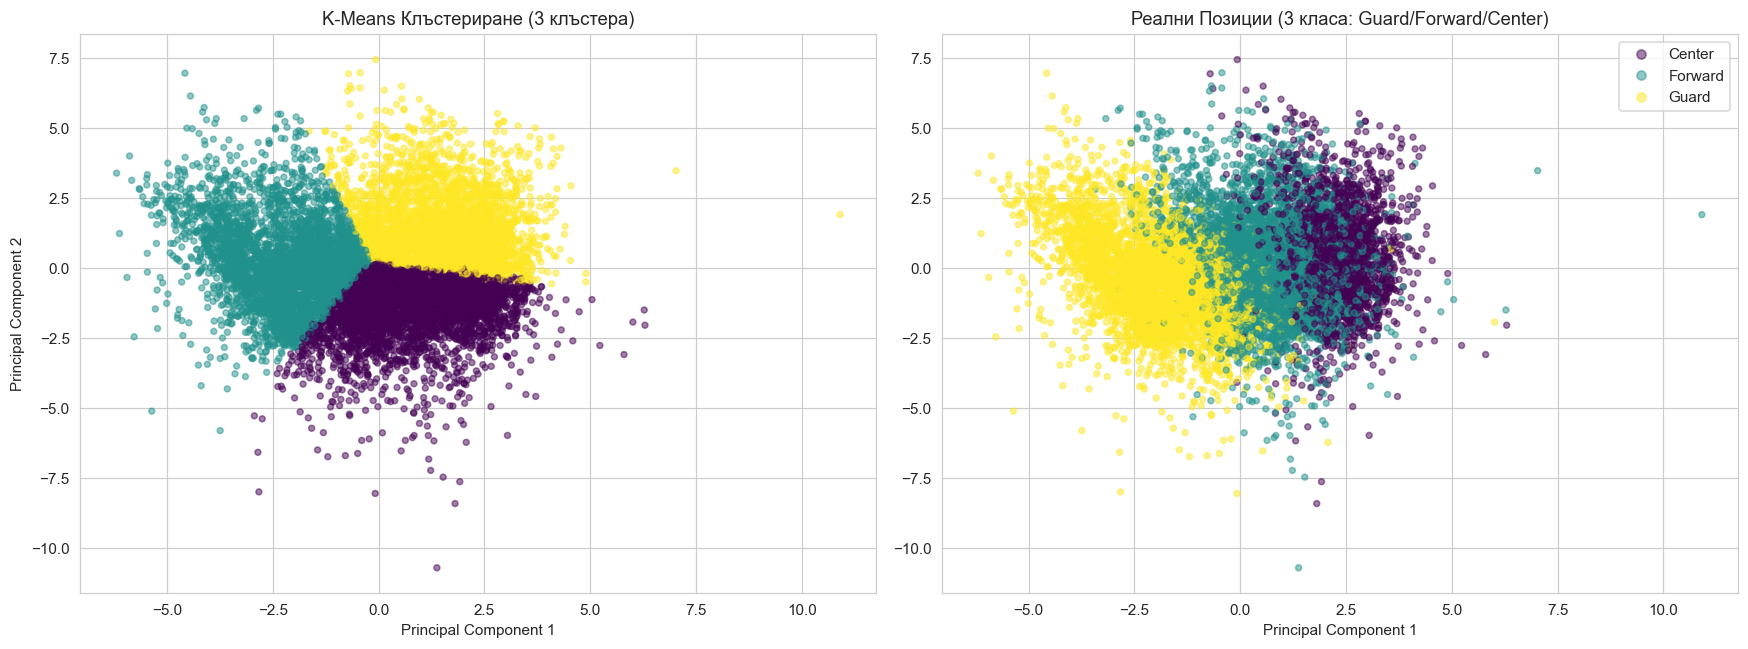

In [19]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

# Скалираме данните (K-Means е чувствителен към различни мерни единици като см и %)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means с 3 клъстера (спрямо модерното разделение: Guard, Forward, Center)
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Adjusted Rand Index: количествена мярка доколко клъстерите съвпадат с реалните позиции.
# ARI=1 -> пълно съвпадение, ARI=0 -> случайно. Не зависи от номерацията на клъстерите.
ari = adjusted_rand_score(y3, clusters)
print(f'Adjusted Rand Index (K-Means vs реални 3 групи): {ari:.3f}')

# PCA за намаляване до 2 измерения
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Оцветяване по K-Means клъстери
axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', alpha=0.5, s=15)
axes[0].set_title('K-Means Клъстериране (3 клъстера)')
axes[0].set_xlabel('Principal Component 1')
axes[0].set_ylabel('Principal Component 2')

# Оцветяване по истинската 3-класова позиция
scatter_real = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=y3, cmap='viridis', alpha=0.5, s=15)
axes[1].set_title('Реални Позиции (3 класа: Guard/Forward/Center)')
axes[1].set_xlabel('Principal Component 1')

handles, _ = scatter_real.legend_elements()
axes[1].legend(handles, CLASS3)

plt.tight_layout(); plt.show()

**Тълкуване (важно).** Цветовете на двата панела **не са пряко сравними** — номерата на клъстерите при K-Means са произволни, затова сравняваме *формата* на групите, а съвпадението измерваме количествено с **Adjusted Rand Index (ARI ≈ 0.30)**.

ARI около 0.30 означава **умерено, а не пълно** съвпадение: без никакви етикети K-Means улавя **най-едрото разделение** (центровете, които са по-високи и тежки, се отделят ясно от гардовете), но **обърква съседните профили** — точно както контролираният ни модел бърка между съседните позиции. Тоест неконтролираното обучение потвърждава същия извод: позицията е реален сигнал в данните, но границите между съседните роли са обективно размити. (Ако K-Means възпроизвеждаше позициите идеално, ARI щеше да е близо до 1.)

## 3. Сравнение с други анализи в Kaggle

Прегледът на публичните notebook-и върху датасета *justinas/nba-players-data* показва, че повечето
от тях се различават по подход от настоящия проект:

| Анализ (Kaggle) | Подход | Разлика спрямо този проект |
|---|---|---|
| *Data Analysis of NBA Players* (kharismabima) | Описателен EDA — тенденции в ръст/тегло/произход през годините | Само визуализация, без предсказателен модел |
| *NBA Players Clustering using PCA and KMeans* (terrycheng) | **Неконтролирано** клъстериране — PCA + KMeans | Намира групи играчи **без етикети**; ние решаваме **контролирана** класификация |
| *NBA Players Clustering Model* (chen2870) | KMeans върху статистики | Броят клъстери се избира евристично; ние имаме истинска целева променлива `Pos` |
| *NBA Clustering Analysis* (bilalwaheed) | Клъстериране на стилове на игра | Открива „архетипи", не official позиции |
| *NBA All-Stars Analysis* (kennygtanaka, GitHub) | PCA / Sparse PCA + класификация на All-Star играчи | Друга целева променлива (All-Star, не позиция) |

**Основни разлики на нашия подход:**
1. **Контролирана класификация вместо клъстериране.** Повечето Kaggle анализи прилагат KMeans,
   защото оригиналният датасет **няма** колона за позиция. Ние решихме точно този проблем —
   *обогатихме* датасета с външен източник (`Seasons_Stats`) и така превърнахме задачата в
   класификация с реални етикети, която може да се оцени с точност и confusion matrix.
2. **Връзка с клъстеринга.** Интересно е, че clustering notebook-ите често откриват именно ~5
   естествени групи играчи — нашият контролиран резултат потвърждава, че позицията е реален,
   измерим сигнал в данните, а не само удобна етикетна схема.
3. **Коректна валидация.** Прегледаните notebook-и не адресират структурата *играч × сезон*. Ние
   показахме, че случайният `KFold` завишава точността с ~6 пр.п. поради изтичане на данни, и
   използвахме `GroupKFold`.

*Източници:* [NBA Players — Kaggle](https://www.kaggle.com/datasets/justinas/nba-players-data) ·
[Clustering PCA+KMeans](https://www.kaggle.com/terrycheng/nba-players-clustering-using-pca-and-kmeans) ·
[NBA Clustering Analysis](https://www.kaggle.com/code/bilalwaheed/nba-clustering-analysis) ·
[NBA All-Stars Analysis](https://github.com/kennygtanaka/NBA-All-Stars-Analysis)

## 4. Изводи

1. **Random Forest** предсказва игровата позиция с точност ~**0.78** (5 класа) при коректна групова
   кръстосана валидация — стабилен резултат за задача с реално припокриващи се класове.
2. **Ансамбълът печели** ясно спрямо едно дърво (Decision Tree), което потвърждава ползата от bagging
   и случайния подбор на признаци.
3. **XGBoost** е практически наравно с Random Forest — на този датасет boosting не носи предимство,
   а Random Forest се настройва по-лесно.
4. **Методологията има значение:** случайният `KFold` завишава точността с ~6 пр.п. чрез изтичане на
   данни; `GroupKFold` дава реалната обобщаваща способност. Същото изтичане засяга и OOB оценката.
5. **Най-важни признаци:** ръст, тегло и съотношението борби/асистенции — в пълно съответствие с
   баскетболната интуиция (потвърдено и чрез SHAP).
6. **3-класовият експеримент** (Guard/Forward/Center) повишава точността до ~0.87 и показва, че
   повечето грешки идват от обективното припокриване на съседните позиции.
7. **Неконтролираното обучение** (K-Means) дава умерено съвпадение с реалните позиции (ARI ≈ 0.30):
   улавя едрото разделение център–гард, но обърква съседните роли — същият извод като при
   контролирания модел, че границите между съседните позиции са обективно размити.

---

# ЧАСТ 2 — Прогнозиране на бъдеща кариера на играч

*(Втори практически случай: Random Forest за предсказване дали млад играч ще се превърне в звезда, ролеви играч или ще отпадне от лигата.)*

---

# Предсказване на бъдещата кариера на NBA играч (Rookie → ?)
## От първите два сезона към бъдещето

Целта на този анализ е да **предскажем какво бъдеще очаква един млад играч**, използвайки
**само данните от първите му два сезона** (rookie + sophomore).

### Целева променлива (3 класа) — определена от сезон 3 нататък
* **Out of League (отпада)** — играчът **не достига до 3-ти сезон** в лигата.
* **Role Player (ролеви играч)** — играе 3+ сезона, но със средно **под 12 точки** на мач (сезони 3+).
* **Star / Starter (звезда/титуляр)** — играе 3+ сезона със средно **над 12 точки** на мач (сезони 3+).

### Два ключови методологични принципа
1. **Разделяне във времето (без изтичане на данни).** Признаците идват **само от сезони 1–2**,
   а целевата променлива се изчислява **само от сезони 3+**. Двете множества не се припокриват,
   затова моделът наистина *прогнозира бъдещето*, а не преизчислява нещо, което вече знае.
2. **Без survivorship bias.** Включваме само играчи, дебютирали до сезон **2017-18**, така че към
   края на данните (2022-23) има поне ~5 години, в които бъдещето им вече се е случило и е
   *наблюдаемо*. Иначе млад играч с 2 сезона би бил неправилно етикетиран като „отпаднал".

### Източник на данните

Използва се датасетът [justinas/nba-players-data](https://www.kaggle.com/datasets/justinas/nba-players-data) от Kaggle. Поставете `all_seasons.csv` в папка `data/`.

```python
# pip install kagglehub
import kagglehub, shutil, os
os.makedirs('data', exist_ok=True)
p = kagglehub.dataset_download('justinas/nba-players-data')
shutil.copy(os.path.join(p, 'all_seasons.csv'), 'data/all_seasons.csv')
```

*Забележка:* всички резултати и графики по-долу вече са изчислени и запазени в notebook-а.

### 1. Импортиране на библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.model_selection import (train_test_split, cross_val_score,
                                     StratifiedKFold, GridSearchCV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42

### 2. Зареждане и подготовка на данните

In [2]:
df = pd.read_csv('data/all_seasons.csv', index_col=0)
df = df.sort_values(['player_name', 'season'])

# Номерираме сезоните на всеки играч: 1 = rookie, 2 = sophomore, ...
df['season_num'] = df.groupby('player_name').cumcount() + 1

print(f'Общо редове (играч × сезон): {len(df)}')
print(f'Уникални играчи            : {df["player_name"].nunique()}')

Общо редове (играч × сезон): 12844
Уникални играчи            : 2551


### 3. Подбор на играчи с „наблюдаемо бъдеще" (без survivorship bias)

Запазваме само играчи, които:
- са **дебютирали до сезон 2017-18** (имаме поне ~5 години, за да видим бъдещето им);
- имат **поне 2 изиграни сезона** (нужни ни за признаците).

In [3]:
debut    = df[df['season_num'] == 1].set_index('player_name')['season']
nseasons = df.groupby('player_name')['season_num'].max()

eligible = debut[debut <= '2017-18'].index.intersection(nseasons[nseasons >= 2].index)
d = df[df['player_name'].isin(eligible)]

print(f'Играчи с дебют <= 2017-18 и >= 2 сезона: {len(eligible)}')

Играчи с дебют <= 2017-18 и >= 2 сезона: 1634


### 4. Целева променлива — изчислена от сезон 3 нататък

За всеки играч гледаме **само сезони 3+**: дали изобщо е играл там и каква е средната му
резултатност. Това е „бъдещето", което моделът ще се опита да предскаже.

In [4]:
# Статистика от "бъдещето" (сезони 3+)
future = d[d['season_num'] >= 3].groupby('player_name').agg(
    fut_pts=('pts', 'mean')).reindex(eligible)
played_3plus = d[d['season_num'] >= 3].groupby('player_name').size().reindex(eligible).fillna(0)
future['fut_pts'] = future['fut_pts'].fillna(0)

def future_class(name):
    if played_3plus[name] == 0:
        return 'Out of League'          # не достига 3-ти сезон
    elif future.loc[name, 'fut_pts'] >= 12:
        return 'Star/Starter'           # резултатен в бъдеще
    else:
        return 'Role Player'            # закрепва се, но в ограничена роля

target = pd.Series({n: future_class(n) for n in eligible}, name='career_class')
print('Разпределение на класовете (бъдеще):')
print(target.value_counts())

Разпределение на класовете (бъдеще):
career_class
Role Player      1137
Out of League     264
Star/Starter      233
Name: count, dtype: int64


### 5. Признаци — само от сезони 1 и 2

Сливаме rookie (yr1) и sophomore (yr2) сезон. Освен суровите статистики добавяме:
- **„Sophomore leap" признаци** — разликата между 2-ри и 1-ви сезон (`*_growth`), която улавя
  тенденцията на развитие;
- **`draft_num`** — номер в драфта (силен предиктор; недрафтираните получават условно 61);
- **`gp` (изиграни мачове)** — индикатор за доверие на треньора и здраве.

In [5]:
r1 = d[d['season_num'] == 1].set_index('player_name')
r2 = d[d['season_num'] == 2].set_index('player_name')
feat = r1.join(r2, lsuffix='_yr1', rsuffix='_yr2', how='inner')

# "Sophomore leap" — растеж между двата сезона
for c in ['pts', 'reb', 'ast', 'net_rating']:
    feat[f'{c}_growth'] = feat[f'{c}_yr2'] - feat[f'{c}_yr1']

# Номер в драфта (Undrafted -> 61)
feat['draft_num'] = pd.to_numeric(feat['draft_number_yr1'], errors='coerce').fillna(61)

FEATURES = [
    'age_yr1', 'player_height_yr1', 'player_weight_yr1', 'draft_num',
    'gp_yr1', 'pts_yr1', 'reb_yr1', 'ast_yr1', 'net_rating_yr1', 'usg_pct_yr1', 'ts_pct_yr1',
    'gp_yr2', 'pts_yr2', 'reb_yr2', 'ast_yr2', 'net_rating_yr2',
    'pts_growth', 'reb_growth', 'ast_growth', 'net_rating_growth',
]

feat = feat.dropna(subset=FEATURES)
y = target.reindex(feat.index)
X = feat[FEATURES]
print(f'X: {X.shape}, y: {y.shape}, класове: {y.nunique()}')

X: (1634, 20), y: (1634,), класове: 3


**Проверка, че няма изтичане на данни.** Признакът `pts_yr2` корелира с бъдещата
резултатност, но това е **легитимна прогнозна връзка**, а не тавтология — целевата променлива
се изчислява от *други* сезони (3+), които изобщо не участват в признаците.

In [6]:
corr = feat['pts_yr2'].corr(future['fut_pts'].reindex(feat.index))
print(f'Корелация pts_yr2 (признак) с fut_pts (от сезони 3+): {corr:.3f}')
print('-> легитимна прогноза: умерена корелация, а не 1.0 (както би било при изтичане)')

Корелация pts_yr2 (признак) с fut_pts (от сезони 3+): 0.760
-> легитимна прогноза: умерена корелация, а не 1.0 (както би било при изтичане)


### 6. Разпределение на класовете

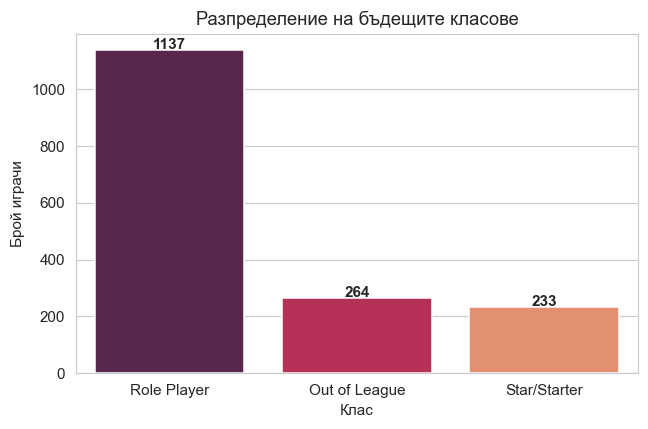

In [7]:
plt.figure(figsize=(6, 4))
order = y.value_counts().index
sns.countplot(x=y, order=order, palette='rocket')
plt.title('Разпределение на бъдещите класове')
plt.xlabel('Клас'); plt.ylabel('Брой играчи')
for i, v in enumerate(y.value_counts()[order]):
    plt.text(i, v + 5, str(v), ha='center', fontweight='bold')
plt.tight_layout(); plt.show()

Класовете са **небалансирани** (`Role Player` доминира). Затова:
- ще използваме `class_weight='balanced'`, за да не игнорира моделът редките класове;
- ще гледаме **macro F1** (а не само accuracy), който усреднява по класове и наказва за пренебрегване на малцинствата;
- ще сравняваме с **базова линия** = винаги да предсказваме мажоритарния клас.

### 7. Обучение, кръстосана валидация и базова линия

Използваме `RandomForestClassifier` с `class_weight='balanced'`. Освен единичен train/test split,
прилагаме **5-кратна стратифицирана кръстосана валидация** (изискване на проекта) и сравняваме с
тривиалната базова линия.

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced',
                            random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X_train, y_train)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_acc = cross_val_score(rf, X, y, cv=cv, scoring='accuracy', n_jobs=-1)
cv_f1  = cross_val_score(rf, X, y, cv=cv, scoring='f1_macro', n_jobs=-1)
baseline = y.value_counts(normalize=True).max()

print(f'Holdout точност           : {accuracy_score(y_test, rf.predict(X_test)):.3f}')
print(f'CV точност (5-fold)       : {cv_acc.mean():.3f} +/- {cv_acc.std()*2:.3f}')
print(f'CV macro-F1 (5-fold)      : {cv_f1.mean():.3f} +/- {cv_f1.std()*2:.3f}')
print(f'Базова линия (мажоритарен): {baseline:.3f}')
print(f'Прираст над базовата линия: {(cv_acc.mean()-baseline)*100:+.1f} проц. пункта')

Holdout точност           : 0.731
CV точност (5-fold)       : 0.753 +/- 0.032
CV macro-F1 (5-fold)      : 0.592 +/- 0.051
Базова линия (мажоритарен): 0.696
Прираст над базовата линия: +5.8 проц. пункта


### 8. Оптимизация на хиперпараметри (`GridSearchCV`)

Оптимизираме по **macro-F1**, защото при небалансирани класове той е по-информативен от accuracy.

In [9]:
param_grid = {
    'n_estimators':     [200, 300],
    'max_depth':        [8, 12, None],
    'min_samples_leaf': [1, 2, 4],
}
grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1),
    param_grid, cv=cv, scoring='f1_macro', n_jobs=-1, verbose=1)
grid.fit(X_train, y_train)

best_rf = grid.best_estimator_
print('Най-добри параметри:', grid.best_params_)
print(f'Най-добър CV macro-F1: {grid.best_score_:.3f}')
print(f'\nHoldout точност (оптимизиран): {accuracy_score(y_test, best_rf.predict(X_test)):.3f}')

Fitting 5 folds for each of 18 candidates, totalling 90 fits


Най-добри параметри: {'max_depth': 8, 'min_samples_leaf': 4, 'n_estimators': 300}
Най-добър CV macro-F1: 0.642

Holdout точност (оптимизиран): 0.737


### 9. Резултати — матрица на грешките и важност на признаците

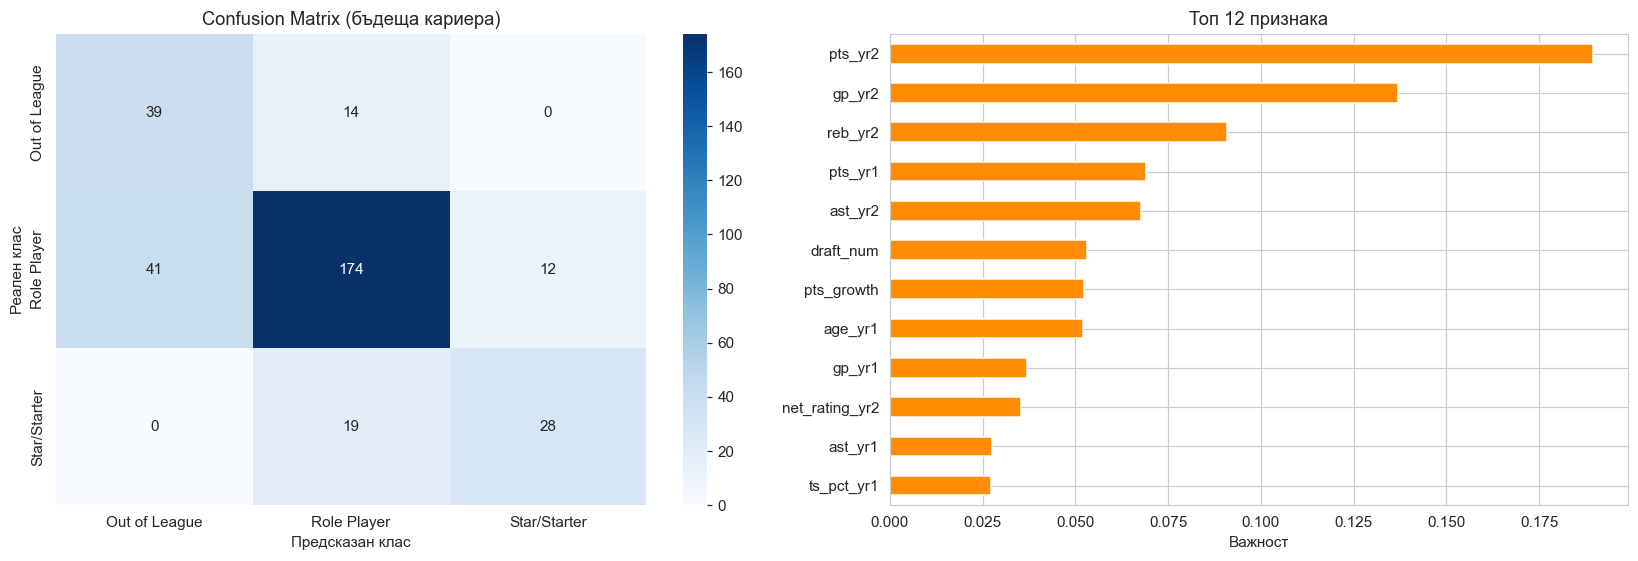

               precision    recall  f1-score   support

Out of League       0.49      0.74      0.59        53
  Role Player       0.84      0.77      0.80       227
 Star/Starter       0.70      0.60      0.64        47

     accuracy                           0.74       327
    macro avg       0.68      0.70      0.68       327
 weighted avg       0.76      0.74      0.74       327



In [10]:
y_pred = best_rf.predict(X_test)
labels = ['Out of League', 'Role Player', 'Star/Starter']

fig, axes = plt.subplots(1, 2, figsize=(15, 5.2))

cm = confusion_matrix(y_test, y_pred, labels=labels)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_xlabel('Предсказан клас'); axes[0].set_ylabel('Реален клас')
axes[0].set_title('Confusion Matrix (бъдеща кариера)')

imp = pd.Series(best_rf.feature_importances_, index=FEATURES).sort_values().tail(12)
imp.plot.barh(ax=axes[1], color='darkorange')
axes[1].set_xlabel('Важност'); axes[1].set_title('Топ 12 признака')

plt.tight_layout(); plt.show()

print(classification_report(y_test, y_pred, labels=labels))

Благодарение на `class_weight='balanced'` моделът **не пренебрегва редките класове**: улавя
значителна част от бъдещите „отпаднали" (Out of League) и „звезди" (Star/Starter), а не просто
предсказва доминиращия Role Player. Най-силни предиктори са **резултатността и изиграните мачове
във втория сезон** и **номерът в драфта** — логично, защото те отразяват както таланта, така и
доверието на организацията към играча.

### 10. Обяснителен ИИ (SHAP) — защо моделът предсказва „звезда"?

Чрез SHAP разглеждаме кои признаци тласкат прогнозата към класа **Star/Starter**.

SHAP — глобална важност за класа 'Star/Starter':


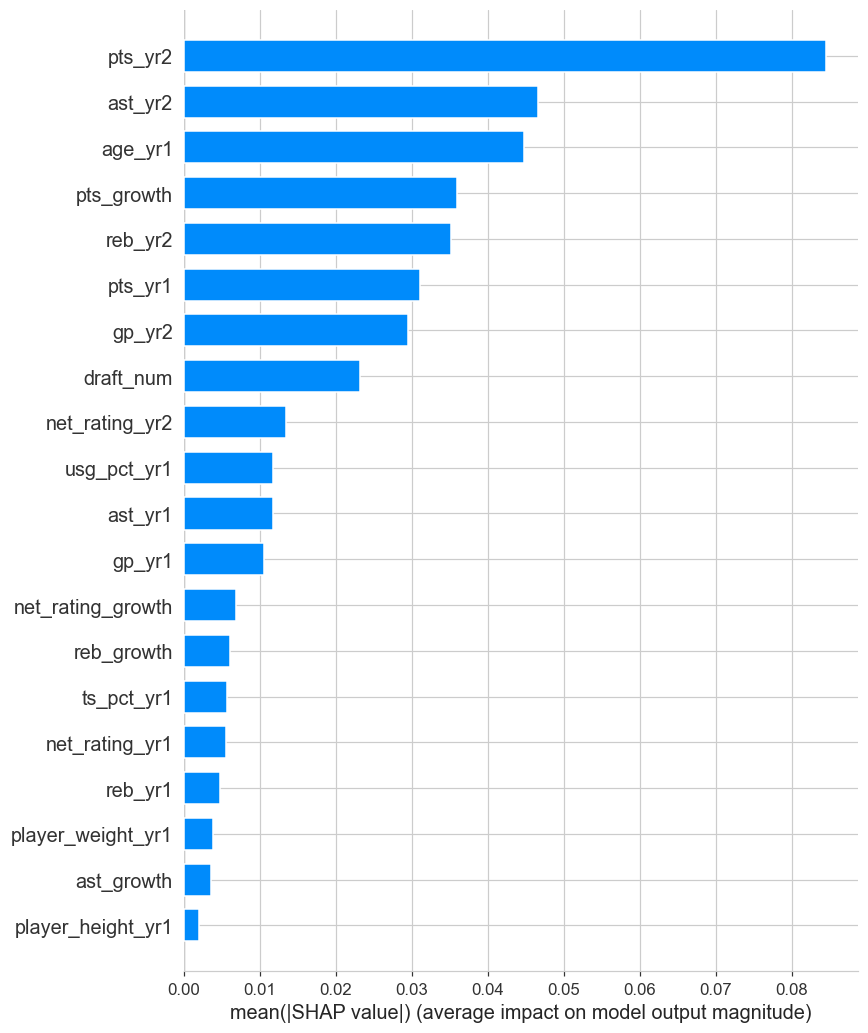

In [11]:
shap.initjs()
explainer = shap.TreeExplainer(best_rf)

X_sample = X_test.head(150)
shap_obj = explainer(X_sample)

star_idx = list(best_rf.classes_).index('Star/Starter')
print("SHAP — глобална важност за класа 'Star/Starter':")
shap.summary_plot(shap_obj[:, :, star_idx], X_sample, plot_type='bar', show=True)

**Изводи от SHAP.** Тъй като целевата променлива се изчислява от сезони 3+, които **не участват**
в признаците, изводите вече **не са тавтологични**. Виждаме, че бъдещата звездност се определя
най-силно от резултатността и обема игра във втория сезон, от растежа спрямо първия сезон
(„sophomore leap") и от позицията в драфта — т.е. ранните сигнали наистина носят прогнозна
информация за бъдещето.

## Сравнение с други анализи в Kaggle

Прогнозирането на кариерата на NBA новобранци е популярна задача. Най-известният еталон е
**„5-Year NBA Rookie Classification"** — предсказване дали играч ще изкара **поне 5 сезона** в
лигата. Сравнението с тези анализи показва къде нашият подход се различава.

| Анализ | Цел (target) | Признаци | Модел / точност | Разлика спрямо нашия проект |
|---|---|---|---|---|
| **5-Year Rookie Classification** (Kaggle / mexwell) | **Бинарна**: ≥5 сезона да/не | само **rookie** сезон | LogReg ~0.72; RF ~0.75 | Ние имаме **3 класа** (отпада/ролеви/звезда), не само оцеляване |
| *NBA Rookie Longevity Project* (mamadoudiallo) | Бинарна дълготрайност | rookie статистики | LogReg / RF | Не адресира survivorship bias; ние филтрираме по дебют |
| *Predictive Modeling of NBA Player Performance* (xreina8) | Регресия на бъдеща продуктивност | сезонни статистики | различни регресори | Ние решаваме класификация с интерпретируеми класове |
| *Predicting NBA Hall of Famers* (Medium / Mamidyala) | Бинарна: HoF да/не | rookie сезон | класификация | Друг, много по-рядък клас (екстремен дисбаланс) |

**Основни разлики на нашия подход:**
1. **3 класа вместо бинарна оцеляване-задача.** Стандартният Kaggle еталон предсказва само „ще
   изкара ли 5 години". Ние разделяме бъдещето на **отпада / ролеви / звезда** — по-информативно,
   защото различава *оцеляване* от *качество* на кариерата.
2. **Два сезона + „sophomore leap".** Повечето анализи ползват **само rookie** сезона. Ние добавяме
   втория сезон и **признаци за растеж** (`*_growth`), които улавят траекторията на развитие.
3. **Изрично третиране на survivorship bias.** Прегледаните notebook-и обикновено не го адресират —
   ние включваме само играчи с вече „случило се" бъдеще (дебют ≤ 2017-18).
4. **Съпоставими резултати.** Нашата CV точност **~0.75** е на нивото на тунинговано Random Forest
   при бинарния еталон (~0.75) — а решаваме **по-трудна 3-класова** задача. Затова сравняваме и
   **прираста над базовата линия** и **macro-F1**, а не само суровата точност (различният брой
   класове прави самата accuracy несравнима директно).

*Източници:* [5-Year NBA Rookie Classification](https://www.kaggle.com/datasets/mexwell/5-year-nba-rookie-classification) ·
[NBA Rookie Longevity Project](https://www.kaggle.com/code/mamadoudiallo/nba-rookie-longevity-project) ·
[Predictive Modeling of NBA Player Performance](https://www.kaggle.com/code/xreina8/predictive-modeling-of-nba-player-performance) ·
[Logistic Regression — 5-Year Rookie (Medium)](https://medium.com/@ammasanaswar/logistic-regression-analysis-5-year-nba-rookie-classification-ab6d43c2a1e4)

## Изводи

1. **Поставихме коректна прогнозна задача:** признаци от сезони 1–2 → бъдеще от сезони 3+. Така
   няма изтичане на данни и резултатите отразяват реална прогнозна способност.
2. **Премахнахме survivorship bias**, като включихме само играчи с вече „случило се" бъдеще
   (дебют до 2017-18).
3. Моделът постига **CV точност ~0.75** при **базова линия ~0.70**, а по-важното — благодарение на
   `class_weight='balanced'` и оптимизация по **macro-F1** разпознава и трите класа, включително
   редките „звезди" и „отпаднали".
4. **Най-силни предиктори** за бъдещето: резултатност и изиграни мачове във втория сезон, растежът
   между двата сезона и номерът в драфта.
5. Задачата е по-трудна от класификацията на позиция (по-малко сигнал в данните, по-голяма
   случайност в кариерите) — което е очаквано: бъдещето на един спортист зависи и от множество
   фактори извън ранната статистика (контузии, смяна на отбор, развитие).